# NYCFlights13 Practice Exercise — Flight Patterns, Delays & Weather (2013)

## Dataset Overview

The dataset `nycflights13` is a built-in R package. It provides comprehensive data for all flights departing New York City airports in 2013. It also includes metadata on airlines, airports, weather and planes, which makes it ideal for analysing flight delays, on-time performance, and travel patterns. For detailed attributes and dataset structures, refer to the datasets' documentation within the packages.

## Tasks

I would like for this section of the page to be a practice exercise to test your skills and even hone them. I will provide answers to the questions below to see how you fared.

* **a.** What are the 10 most common destinations for flights from NYC airports in 2013, and what is the total distance travelled to each of these airports? Make a 2-panel figure and display these data graphically.

* **b.** Which airlines have the most flights departing from NYC airports in 2013? Make a table that lists these in descending order of frequency and shows the number of flights for each airline. In your table, list the names of the airlines as well. *Hint:* you can use the `airlines` dataset to look up the airline name based on `carrier` code.


* **c.** Consider only flights that have non-missing arrival delay information. Your answer should include the name of the carrier in addition to the carrier code and the values asked.
    * i. Which carrier had the highest mean arrival delay?
    * ii. Which carrier had the lowest mean arrival delay?

    Make sure that your answer includes the name of the carrier and the calculated mean (±SD) delay times, and use a sensible number of decimal digits.


* **d.** What were the mean values for the weather variables at the origin airport on the top 10 days with the highest departure delays? Contrast this with a similar view on the 10 days with the lowest departure delays. Your table(s) should include the names of origin airports, the dates with the highest (lowest) departure delays, and the mean (±SD) weather variables on these days.

  Can you make any inferences about the effect of weather conditions on flight delays? Are there any problems with this analysis, and how might you improve this analysis for a clearer view of the effect of weather conditions on the ability of flights to depart on time?
  
* **e.** Partition each day into four equal time intervals, e.g. 00:01-06:00, 06:01-12:00, 12:01-18:00, and 18:01-00:00.
    * i.  At each time interval, what is the proportion of flights delayed at departure? Illustrate your finding in a figure.
    * ii.  Based on your analysis, does the chance of being delayed change throughout the day?
        See answer to Question e.i.
    * iii.  For each weekday (1-7) aggregated over 2013, which of the time intervals has the most flights? Create a figure to show your finding.
      

* **f.** Find the 10 planes that spend the longest time (cumulatively) in the air.
    * i.  For each model, what are the cumulative and mean flight times? In this table, also mention their type, manufacturer, model, number of engines, and speed.
    * ii.  Create a table that lists, for each air-plane identified in (i.), each flight (and associated destination) that it undertook during 2013.
    * iii.  Summarise all the in formation in (ii.) on a map of the USA. Use lines to connect departure and destination locations (each labelled).

  Different facets in the figure must be used for each of the 10 planes. You can use the `alpha` value in **ggplot2** such that the colour intensity of overlapping flight lines is proportional to the number of flights taken along the path. For bonus marks, ensure that the curvature of Earth is indicated in the flight lines. *Hint:* such lines would display as curves, not straight lines.


* **g.** Limit this analysis to only the coldest three winter and warmest three summer months (show evidence for how this is decided). For each of these two seasons, create a visualisation to explore if there is a relationship between the mean daily departure delay and the mean daily temperature. Be as economical with your code as possible. Discuss your answer.

## Answers

Most of the answers I write on this section will be without an explaination. I trust that you will read the code and understand what is going on and what the code does. Your search engines and AI should also be able to help interpreting the code where you get lost, or simply contact me on GitHub on the issues pages to discuss any section you do not understand.

In [8]:
options(warn = 1)

# Set to 0 to enable warnings
# Set to 1 to remove warnings

**a. What are the 10 most common destinations for flights from NYC airports in 2013, and what is the total distance travelled to each of these airports? Make a 2-panel figure and display these data graphically.**

In [5]:
# Install packages

install.packages("nycflights13")

Installing package into 'C:/Users/pheme/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'nycflights13' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\pheme\AppData\Local\Temp\RtmpKGEnEj\downloaded_packages


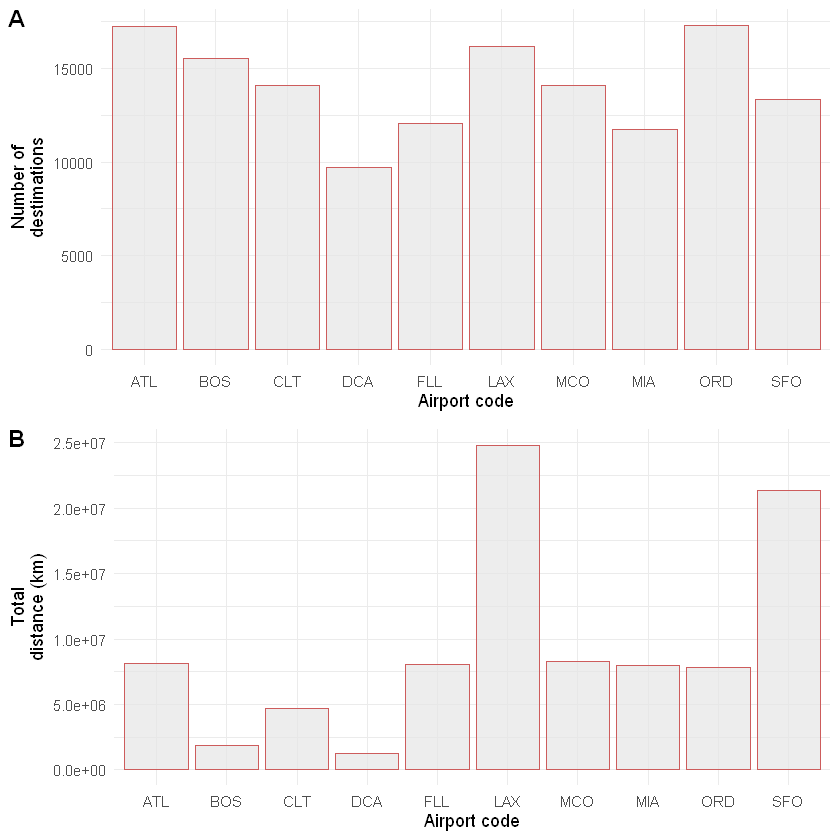

In [10]:
library(tidyverse)
library(ggpubr) # An extension for ggplot2 in tidyverse
library(nycflights13)

tab1 <- flights %>%
  group_by(dest) %>%  
  summarise(n = n(),
            total_distance = sum(distance)) %>% 
  arrange(desc(n)) %>%
  slice(1:10)

plt1 <- ggplot(tab1) +
  geom_col(aes(x = dest, y = n), fill = "grey90", alpha = 0.7,
           colour = "indianred") +
  theme_minimal() +
  labs(x = "Airport code",
       y = "Number of\ndestimations")
plt2 <- ggplot(tab1) +
  geom_col(aes(x = dest, y = total_distance * 0.621371), # convert to km
           fill = "grey90", alpha = 0.7, colour = "indianred") +
  theme_minimal() +
  labs(x = "Airport code",
       y = "Total\ndistance (km)")
ggarrange(plt1, plt2, ncol = 1, labels = "AUTO")

**b. Which airlines have the most flights departing from NYC airports in 2013? Make a table that lists these in descending order of frequency and shows the number of flights for each airline. In your table, list the names of the airlines as well. *Hint:* you can use the `airlines` dataset to look up the airline name based on `carrier` code.**

In [11]:
popular_destinations <- flights %>%
  count(carrier) %>%
  arrange(desc(n)) %>%
  inner_join(airlines, by = "carrier") %>% 
  as_tibble()
head(popular_destinations, n = 16)

carrier,n,name
<chr>,<int>,<chr>
UA,58665,United Air Lines Inc.
B6,54635,JetBlue Airways
EV,54173,ExpressJet Airlines Inc.
DL,48110,Delta Air Lines Inc.
AA,32729,American Airlines Inc.
MQ,26397,Envoy Air
US,20536,US Airways Inc.
9E,18460,Endeavor Air Inc.
WN,12275,Southwest Airlines Co.


The carrier with the highest number of flights departing from NYC airports in 2013 is United Airlines, followed by JetBlue Airways and ExpressJet Airlines.

**c. Consider only flights that have non-missing arrival delay information. Your answer should include the name of the carrier in addition to the carrier code and the values asked.**

* **i. Which carrier had the highest mean arrival delay?**
* **ii. Which carrier had the lowest mean arrival delay?**

**Make sure that your answer includes the name of the carrier and the calculated mean (±SD) delay times, and use a sensible number of decimal digits.**

In [12]:
flights %>%
  filter(!is.na(arr_delay)) %>%
  group_by(carrier) %>%
  summarise(mean_arr_delay = round(mean(arr_delay), 1),
            sd_arr_delay = round(sd(arr_delay), 1)) %>%
  arrange(desc(mean_arr_delay)) %>%
  inner_join(airlines, by = "carrier") %>%
  slice(c(1, n())) %>% 
  as_tibble()

carrier,mean_arr_delay,sd_arr_delay,name
<chr>,<dbl>,<dbl>,<chr>
F9,21.9,61.6,Frontier Airlines Inc.
AS,-9.9,36.5,Alaska Airlines Inc.


The longest arrival delay was on Frontier Airlines that, on average, arrived 21.9 ± 61.5 (mean ± SD) minutes late. On the contrary, Alaska Airlines typically arrived earlier than anticipated by 9.9 ± 36.5 (mean ± SD) minutes.

**d. What were the mean values for the weather variables at the origin airport on the top 10 days with the highest departure delays? Contrast this with a similar view on the 10 days with the lowest departure delays. Your table(s) should include the names of origin airports, the dates with the highest (lowest) departure delays, and the mean (±SD) weather variables on these days.**

**Can you make any inferences about the effect of weather conditions on flight delays? Are there any problems with this analysis, and how might you improve this analysis for a clearer view of the effect of weather conditions on the ability of flights to depart on time?**

In [13]:
top_delay <- bind_rows(
    flights %>% slice_max(order_by = dep_delay, n = 10),
    flights %>% slice_min(order_by = dep_delay, n = 10),
) %>% 
  select(carrier, flight, tailnum, dep_delay, month, day, origin) %>%
  inner_join(weather, by = c("origin", "month", "day")) %>% 
  pivot_longer(cols = temp:visib,
               names_to = "weather_var",
               values_to = "value") %>% 
  na.omit() %>% 
  group_by(carrier, flight, tailnum, dep_delay, weather_var) %>% 
  summarise(mean_weather_var = round(mean(value, na.rm = TRUE), ),
            sd_weather_var = round(sd(value, na.rm = TRUE), 1)) %>% 
  unite("mean_sd", mean_weather_var:sd_weather_var, sep = " ± ") %>% 
  arrange(desc(dep_delay)) %>% 
  pivot_wider(names_from = weather_var, values_from = mean_sd) %>% 
  as_tibble()
top_delay

`summarise()` has grouped output by 'carrier', 'flight', 'tailnum', 'dep_delay'. You can override using the `.groups`
argument.


carrier,flight,tailnum,dep_delay,dewp,humid,precip,pressure,temp,visib,wind_dir,wind_speed,wind_gust
<chr>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
HA,51,N384HA,1301,35 ± 2.7,74 ± 11.3,0 ± 0,1026 ± 3.1,43 ± 5.4,10 ± 0.8,174 ± 98.1,8 ± 6.1,NA
MQ,3535,N504MQ,1137,53 ± 4.5,57 ± 16.3,0 ± 0,1014 ± 1.1,71 ± 5.9,10 ± 0,273 ± 59.3,9 ± 3.4,20 ± 4.1
MQ,3695,N517MQ,1126,24 ± 2.8,48 ± 11.7,0 ± 0,1031 ± 2.8,44 ± 3.7,10 ± 0,267 ± 104.3,9 ± 3.7,21 ± 3.1
AA,177,N338AA,1014,57 ± 2.1,73 ± 14.4,0 ± 0,1018 ± 1,66 ± 5.9,10 ± 0,198 ± 54.5,8 ± 3.3,NA
MQ,3075,N665MQ,1005,73 ± 1.2,83 ± 10.6,0 ± 0,1013 ± 1.2,79 ± 3.7,9 ± 1,99 ± 37.8,8 ± 3.1,NA
DL,2391,N959DL,960,47 ± 2.8,68 ± 13.6,0 ± 0,1013 ± 1.3,58 ± 4.4,10 ± 1.3,159 ± 112.4,10 ± 6.3,NA
DL,2119,N927DA,911,17 ± 5.2,50 ± 14,0 ± 0,1020 ± 4,35 ± 2.3,10 ± 0,298 ± 86.2,12 ± 3.2,22 ± 2.2
DL,2007,N3762Y,899,70 ± 1.1,83 ± 9,0 ± 0,1008 ± 1.7,76 ± 3.7,9 ± 1.7,145 ± 74.3,9 ± 6.8,21 ± NA
DL,2047,N6716C,898,72 ± 1.4,84 ± 3.6,0 ± 0,1012 ± 1.6,77 ± 1.8,9 ± 1.8,73 ± 39.7,10 ± 3.4,NA


Nothing obvious I can see about the effect of weather variables in affecting the departure delay. We would need to do some multivariate stats to assess.

**e. Partition each day into four equal time intervals, e.g. 00:01-06:00, 06:01-12:00, 12:01-18:00, and 18:01-00:00.**
* **i.  At each time interval, what is the proportion of flights delayed at departure? Illustrate your finding in a figure.**

In [14]:
flights_tod <- flights %>%
  mutate(time_of_day = case_when(
    sched_dep_time >= 001  & sched_dep_time <= 600  ~ "00:01-06:00",
    sched_dep_time >= 601  & sched_dep_time <= 1200 ~ "06:01-12:00",
    sched_dep_time >= 1201 & sched_dep_time <= 1800 ~ "12:01-18:00",
    sched_dep_time >= 1801                          ~ "18:01-00:00"
  )) %>% 
  mutate(day_of_week = wday(time_hour))

# Find proportion of delayed flights for each time of day
delay_time <- flights_tod %>%
  filter(!is.na(dep_delay)) %>%
  mutate(dep_delayed = ifelse(dep_delay > 0, "delayed", "ontime")) %>%
  count(time_of_day, dep_delayed) %>%
  group_by(time_of_day) %>%
  mutate(prop_delayed = n / sum(n)) %>%
  filter(dep_delayed == "delayed") %>%
  arrange(prop_delayed) %>% 
  as_tibble()
head(delay_time)

time_of_day,dep_delayed,n,prop_delayed
<chr>,<chr>,<int>,<dbl>
00:01-06:00,delayed,1819,0.2067985
06:01-12:00,delayed,32466,0.2603967
12:01-18:00,delayed,58325,0.4625371
18:01-00:00,delayed,35822,0.5195510


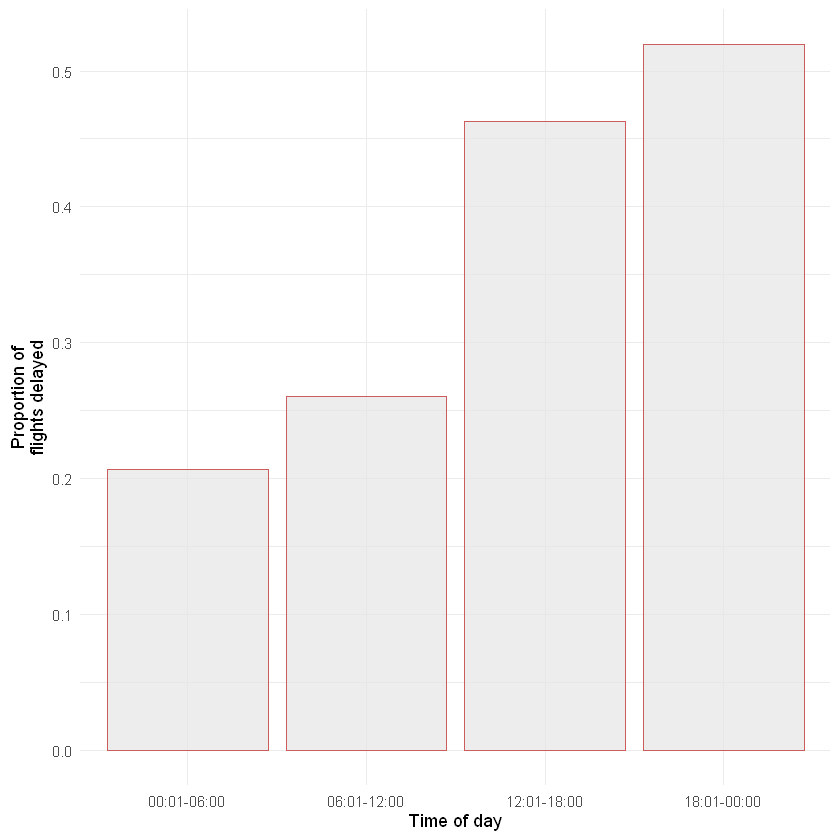

In [15]:
ggplot(delay_time, aes(x = time_of_day, y = prop_delayed)) +
  geom_col(fill = "grey90", alpha = 0.7, colour = "indianred") +
  theme_minimal() +
  labs(x = "Time of day",
       y = "Proportion of\nflights delayed")

About 21% of flights are delayed between midnight and 6:00, 26% are delayed between 6:00-12:00, 46% delays between 12:00-18:00, and 52% delays between 18:00pm and midnight. As the day progresses, the better the chance is of there being a delay.

* **ii.  Based on your analysis, does the chance of being delayed change throughout the day?**

**See answer to Question e.i.**
* **iii.  For each weekday (1-7) aggregated over 2013, which of the time intervals has the most flights? Create a figure to show your finding.**

`summarise()` has grouped output by 'time_of_day'. You can override using the `.groups` argument.


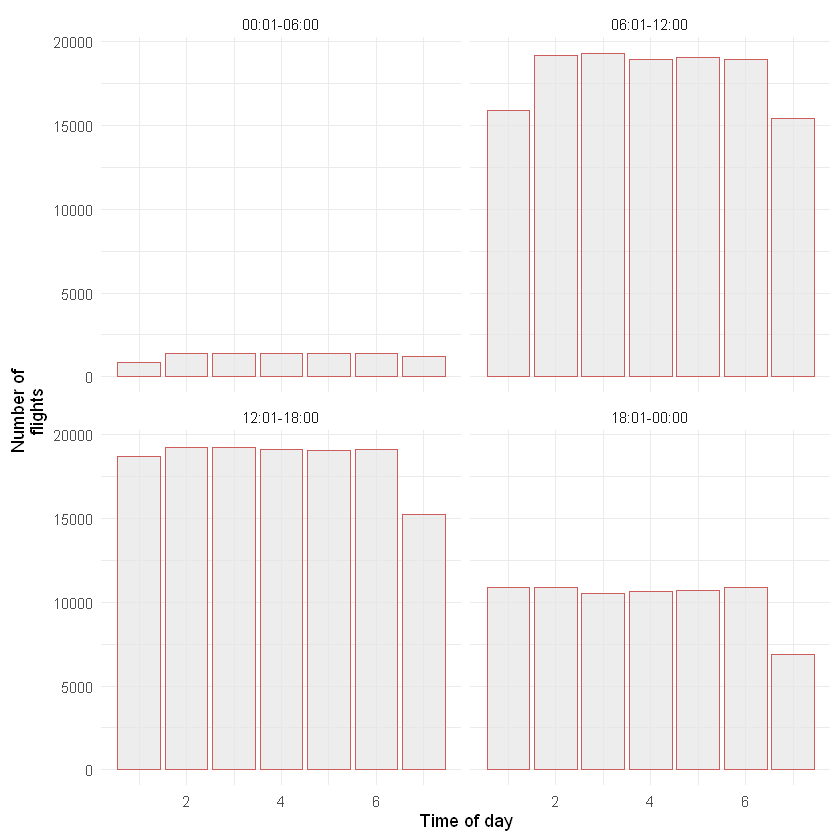

In [17]:
flights_tod %>% 
  group_by(time_of_day, day_of_week) %>% 
  summarise(n_flights = n()) %>% 
  ggplot(aes(x = day_of_week, y = n_flights)) +
    geom_col(fill = "grey90", alpha = 0.7, colour = "indianred") +
    theme_minimal() +
    labs(x = "Time of day",
         y = "Number of\nflights") +
    facet_wrap(~time_of_day)

Midnight to 6-am has the fewest flights, regardless of what day of the week we are looking at -- although Sundays (day 1) and Saturday (day 7) have slightly fewer flights. Similarly, Sun/Sat have slightly fewer flights between 6-am to 6-pm, although the total number of flights are much higher (closer to 20000 flights per day). Evenings from 6-pm to midnight the flights decrease in numbers, and Saturdays have fewer flights during this time than other days.

**f. Find the 10 planes that spend the longest time (cumulatively) in the air.**
* **i.  For each model, what are the cumulative and mean flight times? In this table, also mention their type, manufacturer, model, number of engines, and speed.**

In [18]:
cum_flights <- flights %>%
  group_by(tailnum) %>% 
  summarise(cum_air_time = sum(air_time),
            mean_air_time = round(mean(air_time, na.rm = TRUE), 1)) %>% 
  slice_max(order_by = cum_air_time, n = 10) %>% 
  inner_join(planes, by = "tailnum") %>%
  select(tailnum, cum_air_time, mean_air_time, type, manufacturer, model, engines, speed) %>% 
  as_tibble()
head(cum_flights)

tailnum,cum_air_time,mean_air_time,type,manufacturer,model,engines,speed
<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>
N502UA,97320,340.3,Fixed wing multi engine,BOEING,757-222,2,NA
N512UA,95943,341.4,Fixed wing multi engine,BOEING,757-222,2,NA
N505UA,95591,339.0,Fixed wing multi engine,BOEING,757-222,2,NA
N557UA,87371,337.3,Fixed wing multi engine,BOEING,757-222,2,NA
N518UA,80772,340.8,Fixed wing multi engine,BOEING,757-222,2,NA
N508UA,79998,336.1,Fixed wing multi engine,BOEING,757-222,2,NA


* **ii.  Create a table that lists, for each air-plane identified in (i.), each flight (and associated destination) that it undertook during 2013.**

In [19]:
flight_dest <- flights %>% 
  filter(tailnum %in% cum_flights$tailnum) %>% 
  select(tailnum, origin, dest, time_hour) %>% 
  as_tibble()
head(flight_dest)

tailnum,origin,dest,time_hour
<chr>,<chr>,<chr>,<dttm>
N518UA,JFK,LAX,2013-01-01 11:00:00
N502UA,JFK,SFO,2013-01-01 14:00:00
N512UA,JFK,LAX,2013-01-01 15:00:00
N557UA,JFK,SFO,2013-01-01 17:00:00
N508UA,JFK,SFO,2013-01-01 18:00:00
N591JB,JFK,PSE,2013-01-01 23:00:00


* **iii.  Summarise all the in formation in (ii.) on a map of the USA. Use lines to connect departure and destination locations (each labelled).**

In [20]:
# to be done in due course...

**g. Limit this analysis to only the coldest three winter and warmest three summer months (show evidence for how this is decided). For each of these two seasons, create a visualisation to explore if there is a relationship between the mean daily departure delay and the mean daily temperature. Be as economical with your code as possible. Discuss your answer.**

month,mean_temp
<int>,<dbl>
1,35.6
2,34.3
3,39.9
4,51.7
5,61.8
6,72.2
7,80.1
8,74.5
9,67.4


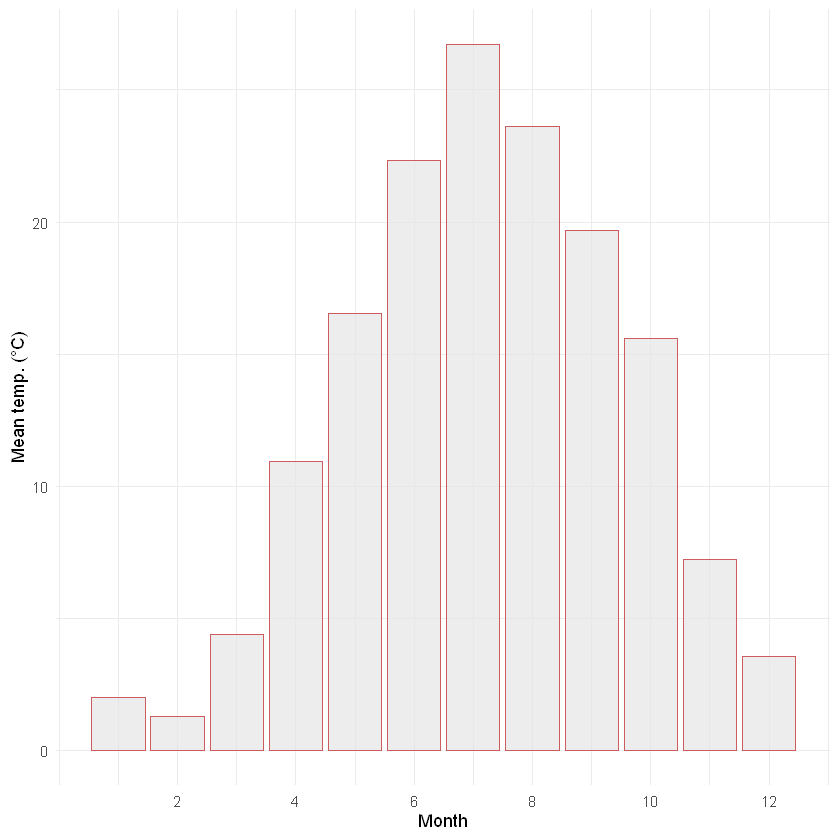

In [21]:
seas <- weather %>% 
  group_by(month) %>% 
  summarise(mean_temp = round(mean(temp, na.rm = TRUE), 1)) %>% 
  as_tibble()
seas

ggplot(seas, aes(x = month, y = (mean_temp - 32)*5/9)) +
  geom_col(fill = "grey90", alpha = 0.7, colour = "indianred") +
  scale_x_continuous(breaks = seq(2, 12, by = 2)) +
  theme_minimal() +
  labs(x = "Month",
       y = "Mean temp. (°C)")

The coldest months are December, January, and February. The warmest time of year is during June, July, August.

Warning message in inner_join(., weather, by = c("origin", "month", "day")):
"Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 8704 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning."


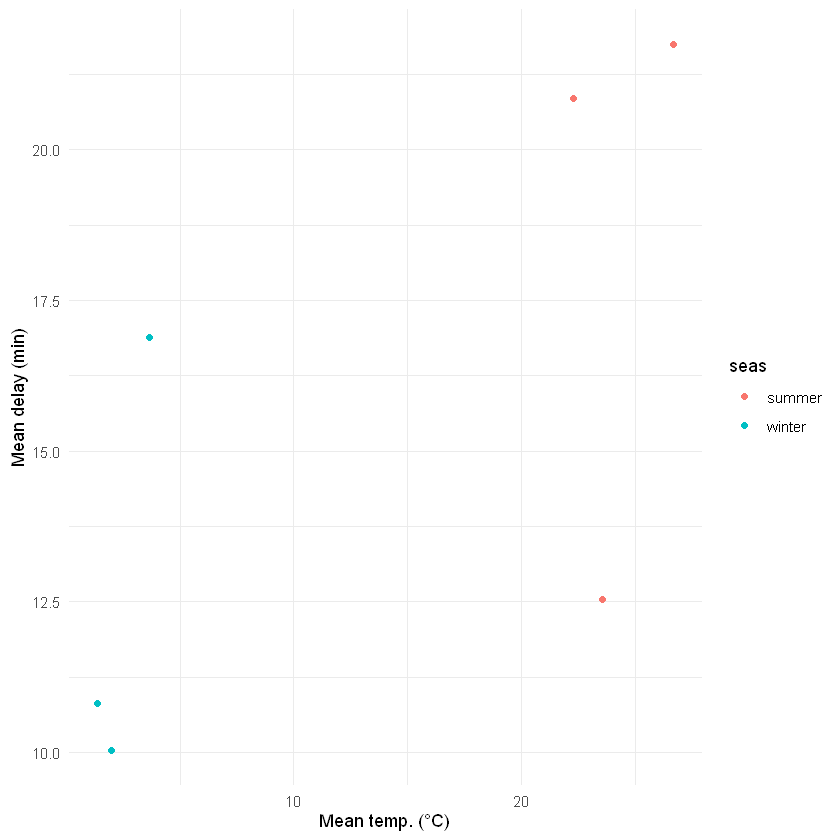

In [22]:
flights %>% 
  filter(month %in% c(12, 1, 2, 6, 7, 8)) %>% 
  inner_join(weather, by = c("origin", "month", "day")) %>% 
  group_by(month) %>% 
  summarise(mean_dep_delay = mean(dep_delay, na.rm = TRUE),
            mean_temp = round(mean(temp, na.rm = TRUE), 1)) %>% 
  mutate(seas = c("winter", "winter", "summer", "summer", "summer", "winter")) %>% 
  ggplot(aes(x = (mean_temp - 32)*5/9, y = mean_dep_delay)) +
    geom_point(aes(col = seas)) +
  theme_minimal() +
  labs(x = "Mean temp. (°C)", y = "Mean delay (min)")

It seems that, in general, shorter delays are experienced during winter months. To fully assess the effect of weather variables on delays, a more detailed statistical analysis will be required.

### *Thank you for participating in the activity, hope you learned something from this and you know where you stand in analysing data.*